# 1、LLMChain的使用

示例1：

In [2]:
from langchain_classic.chains.llm import LLMChain
from langchain_core.prompts import PromptTemplate
import os
import dotenv
from langchain_openai import ChatOpenAI
dotenv.load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 1、创建大模型实例
chat_model = ChatOpenAI(
    model="gpt-4o-mini"
)
# 2、原始字符串模板
template = "桌上有{number}个苹果，四个桃子和 3 本书，一共有几个水果?"
prompt = PromptTemplate.from_template(template)
# 3、创建LLMChain
llm_chain = LLMChain(
    llm=chat_model,
    prompt=prompt
)
# 4、调用LLMChain，返回结果
result = llm_chain.invoke({"number": 2})
print(result)

{'number': 2, 'text': '桌上有 2 个苹果和 4 个桃子，所以水果的总数是：\n\n2 (苹果) + 4 (桃子) = 6 (个水果)\n\n因此，一共有 6 个水果。'}


# 2、SimpleSequentialChain使用(唯一输入与输出)

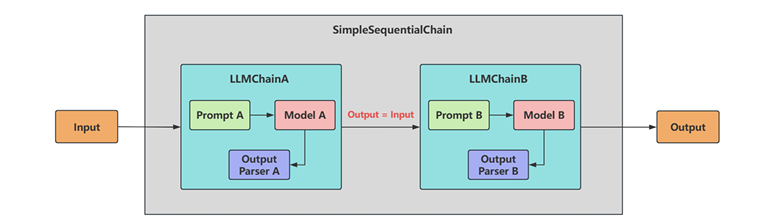

示例1：

In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains import LLMChain

chainA_template = ChatPromptTemplate.from_messages([
    ("system", "你是一位精通各领域知识的知名教授"),
    ("human", "请你尽可能详细的解释一下：{knowledge}")
])

chainA_chains = LLMChain(llm=chat_model,
                         prompt=chainA_template,
                         verbose=True
)
# chainA_chains.invoke({"knowledge":"什么是LangChain？"})

In [4]:
from langchain_core.prompts import ChatPromptTemplate
chainB_template = ChatPromptTemplate.from_messages(
    [
        ("system", "你非常善于提取文本中的重要信息，并做出简短的总结"),
        ("human", "这是针对一个提问的完整的解释说明内容：{description}"),
        ("human", "请你根据上述说明，尽可能简短的输出重要的结论，请控制在20个字以内"),
    ]
)
chainB_chains = LLMChain(llm=chat_model,
                         prompt=chainB_template,
                         verbose=True
                        )

In [6]:
# 导入SimpleSequentialChain
from langchain_classic.chains import SimpleSequentialChain
# 在chains参数中，按顺序传入LLMChain A 和LLMChain B
full_chain = SimpleSequentialChain(
    chains=[chainA_chains, chainB_chains],
    verbose=True
)
response = full_chain.invoke({"input":"什么是langChain？"}) # 唯一的输入key是input
print(response)



> Entering new SimpleSequentialChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
System: 你是一位精通各领域知识的知名教授
Human: 请你尽可能详细的解释一下：什么是langChain？

> Finished chain.
LangChain 是一个用于构建与大型语言模型（LLM）交互的应用程序的框架。它的设计初衷是为了简化和加速开发者在自然语言处理（NLP）和对话系统等领域的工作。LangChain 提供了一整套工具和组件，使得开发者能够更轻松地创建复杂的应用，尤其是在涉及多个步骤和组件的场景中。

以下是 LangChain 的几个核心组成部分以及它的主要特性：

### 1. 模型集成
LangChain 支持多种语言模型的集成，包括 OpenAI 的 GPT 系列、Hugging Face 的 Transformers 模型等。开发者可以方便地切换和比较不同模型的表现。

### 2. 组件化
LangChain 采用组件化的设计，允许你将应用分解成多个易于管理的小块。每个组件可以单独开发、测试和维护，这使得整个系统更加灵活且易于扩展。

### 3. 数据连接
LangChain 提供了对外部数据源的集成能力，这样你可以把实时数据（例如数据库、API 调用等）引入到对话中，让模型的回答更加精准和时效。

### 4. 记忆管理
框架支持对话的上下文记忆，可以追踪用户的上下文信息和交互历史，从而使得模型能够产生更为相关和个性化的响应。

### 5. 流程管理
LangChain 允许用户设计复杂的交互流程，包括决策树、条件分支等。这种能力对于需要多步对话的应用（比如客户支持聊天机器人）尤为重要。

### 6. 适应性
LangChain 的框架可以根据用户的需求进行调整和扩展，支持不同类型的应用场景，例如对话生成、问答系统、内容生成、代码生成等。

### 应用场景
- **对话系统**：构建能够与用户进行自然对话的聊天机器人。
- **信息检索**：集成搜索引擎或数据库，回答用户的具体问题。
- **内容创作**：生成文章、故事或其他创意内容。
- **自动化客服**：通过对用户问题的理解自动提供答案，从而

# 3、SequentialChain使用

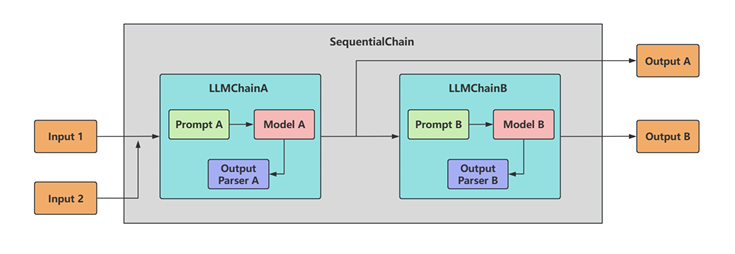

多输出不是chainB有多个输出，大模型通常只有一个输出，而是指的是在chainB输出的基础上chainA也会存在输出内容。

示例1：

In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains import SequentialChain
from langchain_openai import ChatOpenAI
from langchain_classic.chains import LLMChain

# 创建大模型实例
chat_model = ChatOpenAI(model="gpt-4o-mini")

schainA_template = ChatPromptTemplate.from_messages([
        ("system", "你是一位精通各领域知识的知名教授"),
        ("human", "请你先尽可能详细的解释一下：{knowledge}，并且{action}")
])
schainA_chains = LLMChain(llm=chat_model,
                          prompt=schainA_template,
                          verbose=True,
                          output_key="schainA_chains_key"
                          )

schainB_template = ChatPromptTemplate.from_messages([
        ("system", "你非常善于提取文本中的重要信息，并做出简短的总结"),
        ("human", "这是针对一个提问完整的解释说明内容：{schainA_chains_key}"),
        ("human", "请你根据上述说明，尽可能简短的输出重要的结论，请控制在100个字以内"),
])
schainB_chains = LLMChain(llm=chat_model,
                         prompt=schainB_template,
                         verbose=True,
                         output_key='schainB_chains_key' # 不能省略
                          )
# input_variables output_variables必须指明
Seq_chain = SequentialChain(
                            chains=[schainA_chains, schainB_chains],
                            input_variables=["knowledge", "action"],
                            output_variables=["schainA_chains_key","schainB_chains_key"],
                            verbose=True
)
response = Seq_chain.invoke({"knowledge":"明成祖朱棣为什么要奉天靖难","action":"举一个实际的例子"})
print(response)



> Entering new SequentialChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
System: 你是一位精通各领域知识的知名教授
Human: 请你先尽可能详细的解释一下：明成祖朱棣为什么要奉天靖难，并且举一个实际的例子

> Finished chain.


> Entering new LLMChain chain...
Prompt after formatting:
System: 你非常善于提取文本中的重要信息，并做出简短的总结
Human: 这是针对一个提问完整的解释说明内容：明成祖朱棣（1360-1424年）是明朝的第三位皇帝，他的统治始于明朝的靖难之役。这场战争是他为了夺取皇位而进行的一场内战，其背景和动机相当复杂，可以从几个方面进行分析。

### 背景

朱棣是明太祖朱元璋的第四子，起初被封为燕王，驻守北京。在朱元璋去世后，他的长子朱允炆（明惠帝）继位，成为皇帝。然而，朱允炆在位期间，开始对权臣和宗室进行打压，尤其是对亲王的权力限制，引发了许多人的不满。朱棣认为自己的权利和地位受到了侵害，因而产生了夺取皇位的想法。

### 动机

1. **权力欲与不满**：朱棣生性雄心勃勃，向往扩展自己的权力。他对朱允炆的统治感到不满，认为自己应当拥有更大的权力与地位。

2. **政治斗争**：朱允炆采取了清理权臣和削弱宗室的政策，引发了众多宗室的不满与恐惧，朱棣是其中重要的一员。他的许多支持者认为朱允炆的统治方式威胁到了明朝的未来。

3. **正统的“合法性”**：朱棣在发动靖难之役时，宣称自己是为了“恢复明朝的正统”，认为自己比朱允炆更有能力治理国家，试图以此正当化自己的行为。

### 充实的例子

在朱棣准备发动靖难之役的过程中，他得到了大量支持，尤其是来自北方地方豪强的支持。一个实际的例子是，在北方的满洲和蒙古地区，朱棣通过与当地部落的联姻和政治交易，获得了他们的支持。这种支持不仅提供了兵员和军需，还影响到了一定程度上的民众支持，形成了他对手无法匹敌的军事力量。

例如，在战争初期，朱棣的军队以极大的气势攻占了南昌，并向南推进，经过激烈的战斗，最终攻陷了南京，迫使朱允炆自杀。这一系列的军事行动展现了朱棣通过强大的军事战略